<a href="https://colab.research.google.com/github/SLCFLAB/Fintech2026-2/blob/main/DL09_generative_models/GEN_3_Diffusion_DDPM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 생성모델 3. Diffusion Model (DDPM)

**목표**: Stable Diffusion, DALL·E, Sora 등의 기반인 diffusion의 핵심 원리가 **"noise 예측 regression"** 라는 것을 코드로 확인해보기.

| 순서 | 내용 |
|---|---|
| 1 | Forward process: 이미지를 점점 noise로 |
| 2 | 학습 목표와 생성(sampling) 알고리즘 |
| 3 | 2D toy 데이터로 전 과정 시각화 |
| 4 | MNIST 생성 |
| 5 | 빠른 생성: DDIM (1000 step → 50 step) |

- 전체 실행 시간: T4 GPU 기준 약 5~6분

Reference: https://github.com/Jackson-Kang/Pytorch-Diffusion-Model-Tutorial

In [ ]:
import math, time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.datasets as dsets
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(1234)
print("device:", DEVICE)

def show_grid(imgs, nrow=8, title=None, ax=None):
    # imgs 값 범위 [-1, 1] → [0, 1]
    grid = make_grid(imgs.detach().cpu().clamp(-1, 1) * 0.5 + 0.5, nrow=nrow, padding=2, pad_value=1)
    ax = ax or plt.figure(figsize=(nrow * 0.9, (len(imgs) + nrow - 1) // nrow * 0.9)).gca()
    ax.imshow(grid.permute(1, 2, 0)); ax.axis("off")
    if title: ax.set_title(title)

device: cuda


## 1. Forward process: 데이터를 조금씩 noise로 망가뜨리기

매 step마다 이미지를 살짝 줄이고 Gaussian noise를 조금 더함. $T=1000$ step 후엔 **순수 noise** 가 됨.

$$x_t = \sqrt{1-\beta_t}\, x_{t-1} + \sqrt{\beta_t}\, \epsilon, \quad \epsilon \sim N(0, I)$$

- $\beta_t$: t번째 step에서 추가하는 noise 양 (**variance schedule**). DDPM 논문은 $10^{-4}$ → $0.02$ 로 선형 증가
- 핵심 성질: 1000번 반복할 필요 없이 **$x_0$ 에서 $x_t$ 로 한 번에 점프** 가능 ($\alpha_t = 1 - \beta_t$, $\bar\alpha_t = \prod_{s\le t}\alpha_s$)

$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1 - \bar\alpha_t}\, \epsilon$$

→ $\sqrt{\bar\alpha_t}$ = 원본 신호 비율, $\sqrt{1-\bar\alpha_t}$ = noise 비율. 이 성질 덕분에 학습 때 임의의 t를 바로 샘플링할 수 있음.

**이 과정엔 학습할 것이 없음** (정해진 공식). 학습하는 건 반대 방향(noise → 데이터)뿐임.

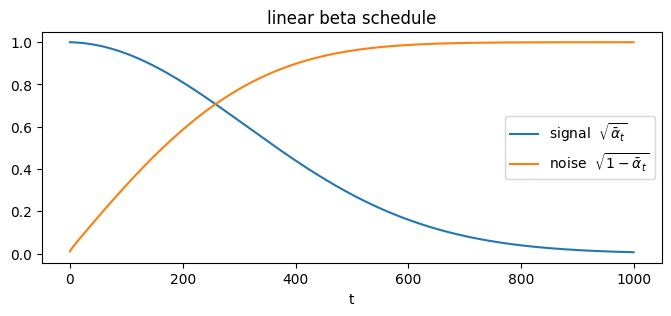

In [ ]:
class Diffusion(nn.Module):
    # 기존 수업 코드의 Diffusion 클래스 기반. 이미지([B,C,H,W])와 2D 점([B,2]) 모두에 쓸 수 있게 일반화함
    def __init__(self, model, n_times=1000, beta_minmax=(1e-4, 2e-2)):
        super().__init__()
        self.model = model                  # noise 예측 네트워크 ε_θ(x_t, t)
        self.n_times = n_times
        betas = torch.linspace(*beta_minmax, n_times)          # 선형 variance schedule
        alphas = 1 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)               # ᾱ_t = α_1 · α_2 · ... · α_t
        # register_buffer: 학습 parameter는 아니지만 .to(device) 할 때 같이 이동함
        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alpha_bars", alpha_bars)

    def extract(self, a, t, x):
        # a[t]를 뽑아서 x와 broadcast 가능한 shape으로: [B] → [B, 1, 1, 1] (이미지) or [B, 1] (2D)
        return a[t].view(-1, *([1] * (x.dim() - 1)))

    def make_noisy(self, x0, t):
        # x_t = sqrt(ᾱ_t)·x0 + sqrt(1-ᾱ_t)·ε  (한 번에 점프)
        eps = torch.randn_like(x0)
        ab = self.extract(self.alpha_bars, t, x0)
        return ab.sqrt() * x0 + (1 - ab).sqrt() * eps, eps

    def loss(self, x0):
        # 학습: (1) 랜덤 t 선택 → (2) noise 추가 → (3) 추가한 noise를 예측 → MSE
        t = torch.randint(0, self.n_times, (x0.size(0),), device=x0.device)
        x_t, eps = self.make_noisy(x0, t)
        return F.mse_loss(self.model(x_t, t), eps)

    @torch.no_grad()
    def sample(self, shape, return_traj_at=()):
        # 생성: 순수 noise x_T에서 시작 → 예측한 noise를 조금씩 빼면서 x_0까지
        x = torch.randn(shape, device=self.betas.device)
        traj = {}
        for t in reversed(range(self.n_times)):
            t_batch = torch.full((shape[0],), t, device=x.device, dtype=torch.long)
            eps_pred = self.model(x, t_batch)
            a, ab, b = self.alphas[t], self.alpha_bars[t], self.betas[t]
            # x_{t-1} = 1/sqrt(α_t) · (x_t - β_t/sqrt(1-ᾱ_t) · ε_θ) + sqrt(β_t) · z
            mean = (x - b / (1 - ab).sqrt() * eps_pred) / a.sqrt()
            z = torch.randn_like(x) if t > 0 else torch.zeros_like(x)   # 마지막 step엔 noise 안 더함
            x = mean + b.sqrt() * z
            if t in return_traj_at:
                traj[t] = x.cpu()
        return x, traj


# schedule 시각화 (model 없이 schedule만 확인)
sched = Diffusion(model=None)
t_axis = np.arange(sched.n_times)
plt.figure(figsize=(8, 3))
plt.plot(t_axis, sched.alpha_bars.sqrt(), label=r"signal  $\sqrt{\bar\alpha_t}$")
plt.plot(t_axis, (1 - sched.alpha_bars).sqrt(), label=r"noise  $\sqrt{1-\bar\alpha_t}$")
plt.xlabel("t"); plt.legend(); plt.title("linear beta schedule"); plt.show()

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]


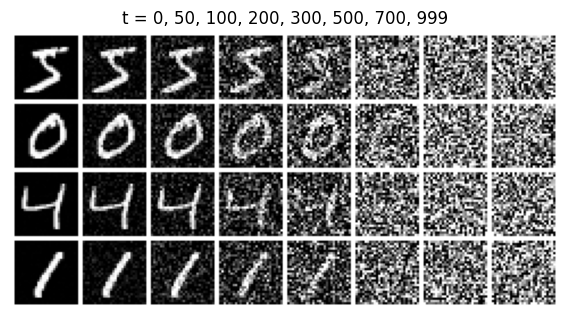

In [ ]:
# MNIST: [0,1] → [-1,1] 로 정규화 (noise N(0,1)과 스케일을 맞추기 위함. DDPM 논문에서도 중요하다고 언급)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
mnist = dsets.MNIST("./data", train=True, download=True, transform=transform)

x0 = torch.stack([mnist[i][0] for i in range(4)])           # [4, 1, 28, 28]
ts = [0, 50, 100, 200, 300, 500, 700, 999]
rows = []
for t in ts:
    x_t, _ = sched.make_noisy(x0, torch.full((4,), t))
    rows.append(x_t)
show_grid(torch.stack(rows, 1).view(-1, 1, 28, 28), nrow=len(ts), title="t = " + ", ".join(map(str, ts)))
plt.show()

t=300 정도면 사람 눈엔 숫자가 거의 안 보이지만 아직 정보가 남아 있음. t=999는 완전한 noise.

## 2. 학습 목표와 생성 알고리즘

**학습** (위 `Diffusion.loss`): 딱 3줄임
1. 학습 이미지 $x_0$ 와 랜덤 시점 $t$ 선택
2. $x_t = \sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\epsilon$ 로 noise 추가
3. 네트워크가 $x_t$ 와 $t$ 를 보고 **추가된 noise $\epsilon$ 을 예측**, loss = MSE

→ GAN 방식과 달리 **평범한 regression** 이라 학습이 안정적임.

**생성** (위 `Diffusion.sample`): $x_T \sim N(0, I)$ 에서 시작해서 $t = T, \dots, 1$ 동안 예측한 noise를 조금씩 제거.
매 step 작은 random noise $z$ 도 다시 더해줌 → 생성 결과가 다양해짐.

**네트워크가 $t$ 를 알아야 하는 이유**: t=999의 입력(거의 noise)과 t=10의 입력(거의 원본)은 제거해야 할 noise 양이 완전히 다름 → **sinusoidal time embedding** 으로 t를 벡터로 바꿔서 네트워크에 넣음 (Transformer의 positional encoding과 같은 아이디어).

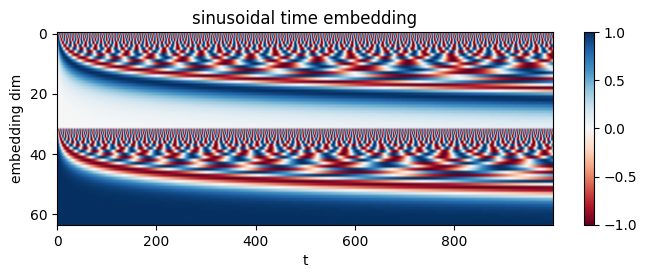

In [ ]:
class SinusoidalPosEmb(nn.Module):
    # 정수 t → dim차원 벡터. 다양한 주파수의 sin/cos 값 → 가까운 t는 비슷한 벡터, 먼 t는 다른 벡터
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        args = t.float()[:, None] * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)

emb = SinusoidalPosEmb(64)(torch.arange(1000))
plt.figure(figsize=(8, 2.5)); plt.imshow(emb.T, aspect="auto", cmap="RdBu")
plt.xlabel("t"); plt.ylabel("embedding dim"); plt.title("sinusoidal time embedding"); plt.colorbar(); plt.show()

## 3. 2D toy 데이터로 전체 과정 보기

2차원 나선(swiss roll) 분포로 학습해서, **noise가 데이터로 바뀌는 과정** 을 직접 봄.
네트워크는 단순한 MLP: 입력 = (점 좌표 2개 + time embedding) → 출력 = 예측한 noise 2개.

In [ ]:
def sample_swiss_roll(n):
    theta = 1.5 * np.pi * (1 + 2 * torch.rand(n))
    x = torch.stack([theta * torch.cos(theta), theta * torch.sin(theta)], 1) / 5
    return x + 0.05 * torch.randn(n, 2)


class ToyDenoiser(nn.Module):
    def __init__(self, hidden=128, t_dim=32):
        super().__init__()
        self.t_emb = SinusoidalPosEmb(t_dim)
        self.net = nn.Sequential(
            nn.Linear(2 + t_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 2),                                  # 예측 noise (x, y)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, self.t_emb(t)], dim=1))     # 좌표와 시간 정보를 이어붙여 입력


toy = Diffusion(ToyDenoiser()).to(DEVICE)
opt = torch.optim.Adam(toy.parameters(), lr=1e-3)
losses = []
for step in range(4000):
    loss = toy.loss(sample_swiss_roll(512).to(DEVICE))            # 위 3줄 학습 그대로
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
print(f"final loss (MA200): {np.mean(losses[-200:]):.3f}")

final loss (MA200): 0.279


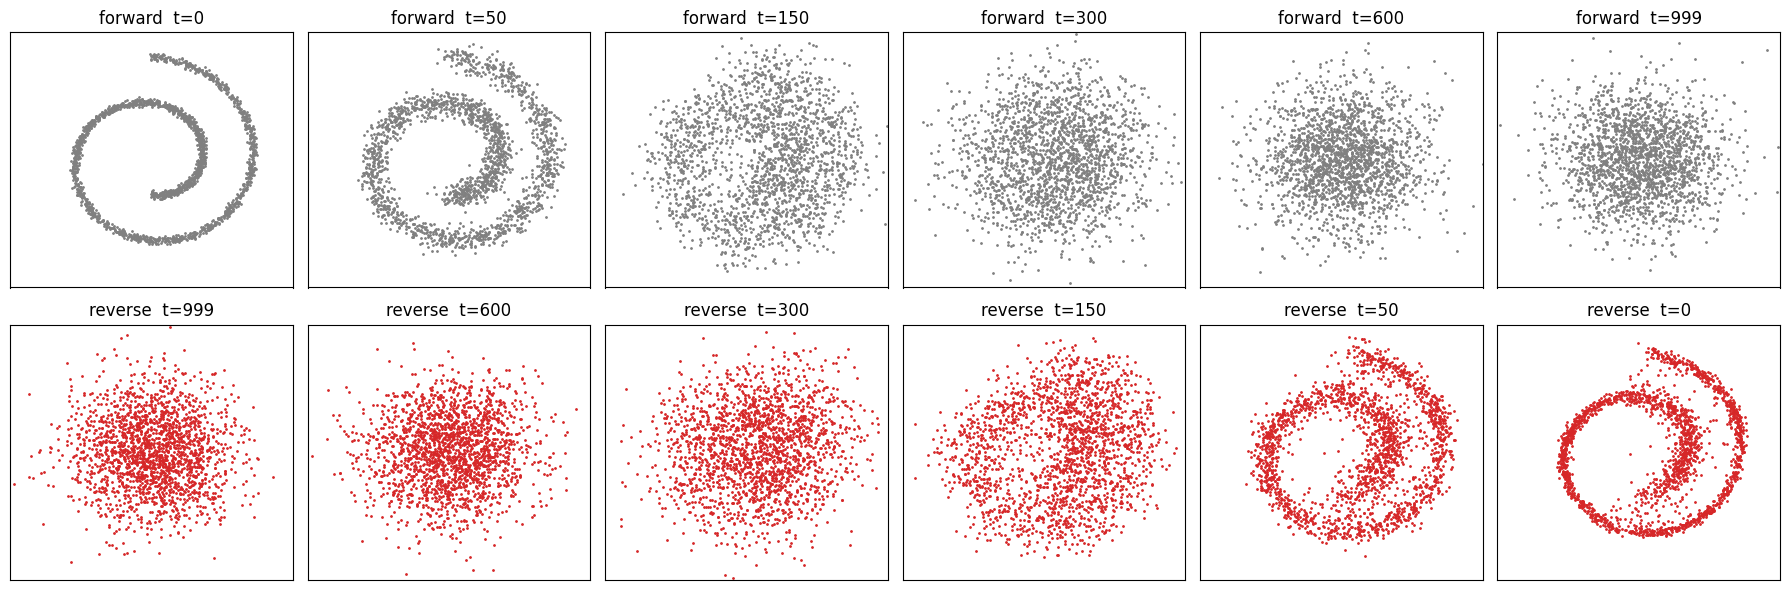

In [ ]:
snap_ts = [999, 600, 300, 150, 50, 0]
real = sample_swiss_roll(2000)
toy.eval()
_, traj = toy.sample((2000, 2), return_traj_at=snap_ts)

fig, axes = plt.subplots(2, len(snap_ts), figsize=(3 * len(snap_ts), 6))
for i, t in enumerate(snap_ts[::-1]):                            # 윗줄: forward (data → noise)
    x_t, _ = toy.make_noisy(real.to(DEVICE), torch.full((2000,), t, device=DEVICE))
    axes[0, i].scatter(*x_t.cpu().T, s=1, c="gray"); axes[0, i].set_title(f"forward  t={t}")
for i, t in enumerate(snap_ts):                                  # 아랫줄: reverse (noise → data)
    axes[1, i].scatter(*traj[t].T, s=1, c="tab:red"); axes[1, i].set_title(f"reverse  t={t}")
for ax in axes.flat:
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

- 윗줄(forward, 정해진 공식): 나선 → 점점 퍼져서 Gaussian 덩어리
- 아랫줄(reverse, 학습된 모델): Gaussian 덩어리 → 점점 모여서 나선
- t=300까지는 거의 Gaussian 그대로이고, 대부분의 "모양"은 **마지막 100~150 step** 에서 만들어짐

## 4. MNIST 생성

### Denoiser 네트워크: 작은 U-Net
- Colab에서 학습/생성이 너무 오래 걸리지 않도록, 실제 DDPM, Stable Diffusion처럼 **U-Net** 구조를 작게 만들어봄 (약 100만 parameter)
  - 해상도를 줄였다가(28→14→7) 다시 키우면서(7→14→28), **같은 해상도끼리 skip connection** 으로 이어줌 → 세밀한 정보 보존
  - 입력과 출력 크기가 같음 (noise 예측이니까)
  - 각 block에 **time embedding을 더해줌** → 지금 몇 번째 step인지 알려줌

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, c_in, c_out, t_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, 3, padding=1)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, padding=1)
        self.norm1, self.norm2 = nn.GroupNorm(8, c_out), nn.GroupNorm(8, c_out)   # batch 크기에 영향 안 받는 정규화
        self.t_proj = nn.Linear(t_dim, c_out)                                    # time embedding → 채널 수 맞춤
        self.skip = nn.Conv2d(c_in, c_out, 1) if c_in != c_out else nn.Identity()

    def forward(self, x, t_emb):
        h = F.silu(self.norm1(self.conv1(x)))
        h = h + self.t_proj(t_emb)[:, :, None, None]         # 시간 정보를 모든 위치에 더함
        h = F.silu(self.norm2(self.conv2(h)))
        return h + self.skip(x)                              # residual connection


class SmallUNet(nn.Module):
    def __init__(self, ch=(32, 64, 128), t_dim=128):
        super().__init__()
        c1, c2, c3 = ch
        self.t_mlp = nn.Sequential(SinusoidalPosEmb(t_dim), nn.Linear(t_dim, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim))
        self.inp   = nn.Conv2d(1, c1, 3, padding=1)
        self.down1 = ResBlock(c1, c1, t_dim)                 # 28x28
        self.pool1 = nn.Conv2d(c1, c1, 4, stride=2, padding=1)   # 28 → 14
        self.down2 = ResBlock(c1, c2, t_dim)                 # 14x14
        self.pool2 = nn.Conv2d(c2, c2, 4, stride=2, padding=1)   # 14 → 7
        self.mid1  = ResBlock(c2, c3, t_dim)                 # 7x7 (가장 압축된 곳)
        self.mid2  = ResBlock(c3, c3, t_dim)
        self.up2   = ResBlock(c3 + c2, c2, t_dim)            # 7 → 14, down2 출력과 concat
        self.up1   = ResBlock(c2 + c1, c1, t_dim)            # 14 → 28, down1 출력과 concat
        self.out   = nn.Conv2d(c1, 1, 3, padding=1)

    def forward(self, x, t):
        te = self.t_mlp(t)
        h1 = self.down1(self.inp(x), te)                     # [B, 32, 28, 28]  ← skip 1
        h2 = self.down2(self.pool1(h1), te)                  # [B, 64, 14, 14]  ← skip 2
        h = self.mid2(self.mid1(self.pool2(h2), te), te)     # [B, 128, 7, 7]
        h = F.interpolate(h, scale_factor=2)                 # [B, 128, 14, 14]
        h = self.up2(torch.cat([h, h2], 1), te)              # [B, 64, 14, 14]
        h = F.interpolate(h, scale_factor=2)                 # [B, 64, 28, 28]
        h = self.up1(torch.cat([h, h1], 1), te)              # [B, 32, 28, 28]
        return self.out(h)                                   # [B, 1, 28, 28]  예측 noise


unet = SmallUNet()
print(f"parameters: {sum(p.numel() for p in unet.parameters()):,}")
print("output shape:", tuple(unet(torch.randn(2, 1, 28, 28), torch.tensor([10, 500])).shape))

parameters: 976,161
output shape: (2, 1, 28, 28)


In [ ]:
EPOCHS = 10           # T4 기준 약 3분. 시간 부족하면 5로 (품질은 떨어짐), 여유 있으면 늘릴수록 좋아짐
loader = DataLoader(mnist, batch_size=128, shuffle=True, num_workers=2, drop_last=True)
diffusion = Diffusion(unet).to(DEVICE)
optimizer = torch.optim.Adam(diffusion.parameters(), lr=1e-3)

t0 = time.time()
for epoch in range(EPOCHS):
    diffusion.train()
    total = 0
    for x, _ in loader:                                      # label 사용 안 함
        loss = diffusion.loss(x.to(DEVICE))
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total += loss.item()
    print(f"epoch {epoch+1}/{EPOCHS}  noise-prediction MSE {total/len(loader):.4f}  ({time.time()-t0:.0f}s)")

epoch 1/10  noise-prediction MSE 0.0712  (22s)
epoch 2/10  noise-prediction MSE 0.0340  (43s)
epoch 3/10  noise-prediction MSE 0.0303  (67s)
epoch 4/10  noise-prediction MSE 0.0285  (88s)
epoch 5/10  noise-prediction MSE 0.0279  (110s)
epoch 6/10  noise-prediction MSE 0.0266  (132s)
epoch 7/10  noise-prediction MSE 0.0263  (156s)
epoch 8/10  noise-prediction MSE 0.0255  (178s)
epoch 9/10  noise-prediction MSE 0.0251  (201s)
epoch 10/10  noise-prediction MSE 0.0247  (224s)


DDPM 1000-step sampling: 7.7s for 64 images


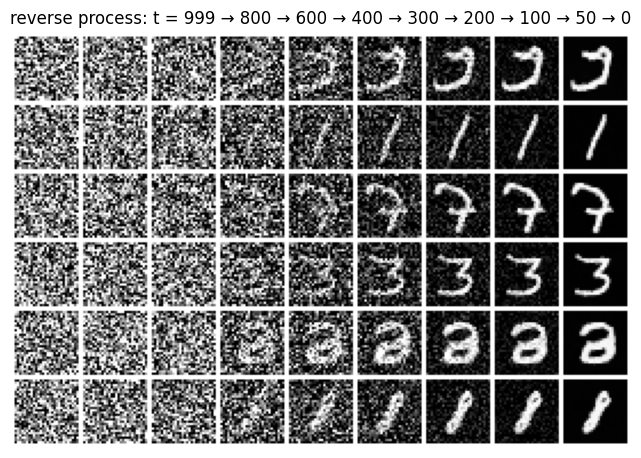

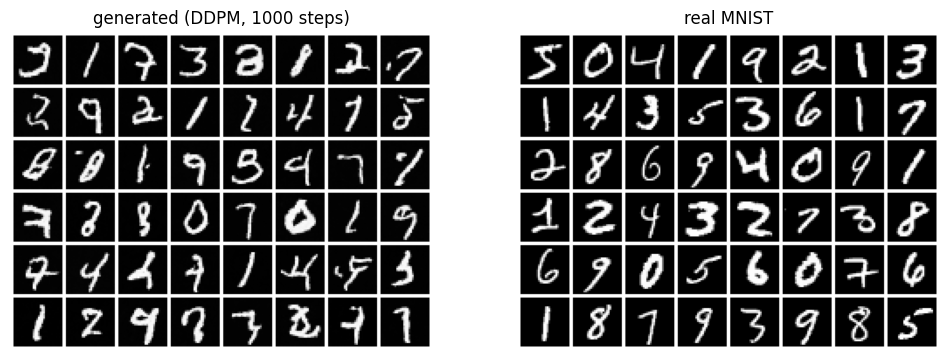

In [ ]:
diffusion.eval()
traj_ts = [999, 800, 600, 400, 300, 200, 100, 50, 0]
t0 = time.time()
samples, traj = diffusion.sample((64, 1, 28, 28), return_traj_at=traj_ts)
ddpm_time = time.time() - t0
print(f"DDPM 1000-step sampling: {ddpm_time:.1f}s for 64 images")

show_grid(torch.stack([traj[t][:6] for t in traj_ts], 1).view(-1, 1, 28, 28), nrow=len(traj_ts),
          title="reverse process: t = " + " → ".join(map(str, traj_ts)))
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
show_grid(samples[:48], nrow=8, title="generated (DDPM, 1000 steps)", ax=axes[0])
show_grid(torch.stack([mnist[i][0] for i in range(48)]), nrow=8, title="real MNIST", ax=axes[1])
plt.show()

- 학습이 단순한 MSE regression이라 GAN처럼 학습이 무너지는 일이 거의 없고, 다양한 숫자가 나옴
- 대신 생성에 네트워크를 **1000번** 실행해야 함 → GAN/VAE(1번)보다 훨씬 느림

## 5. 빠른 생성: DDIM

**재학습 없이** 같은 모델로 step 수만 줄여서 생성하는 방법. 매 step에서
1. 예측한 noise로 $x_0$ 를 추정: $\hat{x}_0 = (x_t - \sqrt{1-\bar\alpha_t}\,\hat\epsilon) / \sqrt{\bar\alpha_t}$
2. 그 $\hat{x}_0$ 를 **훨씬 앞의 시점** $t'$ 로 다시 보냄: $x_{t'} = \sqrt{\bar\alpha_{t'}}\,\hat{x}_0 + \sqrt{1-\bar\alpha_{t'}}\,\hat\epsilon$

→ 1000 step을 50 step으로 건너뛸 수 있음. (실제 Stable Diffusion도 20~50 step 정도로 생성함)

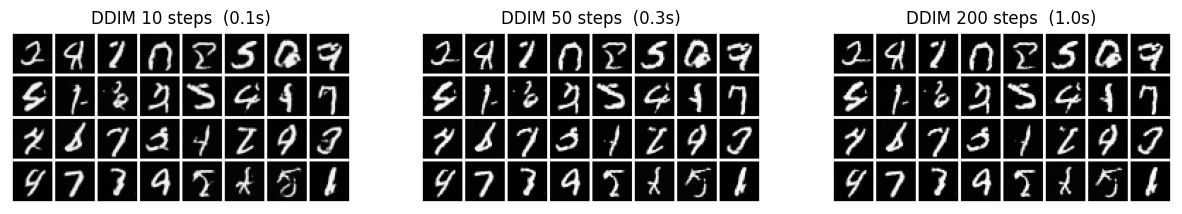

In [ ]:
@torch.no_grad()
def ddim_sample(diff, shape, n_steps=50):
    ts = torch.linspace(diff.n_times - 1, 0, n_steps).long().tolist()     # 999, 979, ..., 0 중 n_steps개만 방문
    x = torch.randn(shape, device=DEVICE)
    for i, t in enumerate(ts):
        ab = diff.alpha_bars[t]
        eps = diff.model(x, torch.full((shape[0],), t, device=DEVICE, dtype=torch.long))
        x0_hat = ((x - (1 - ab).sqrt() * eps) / ab.sqrt()).clamp(-1, 1)   # 1) x0 추정 (픽셀 범위 [-1,1]로 제한)
        eps = (x - ab.sqrt() * x0_hat) / (1 - ab).sqrt()                   #    clamp한 x0와 일관되게 noise 다시 계산
        ab_next = diff.alpha_bars[ts[i + 1]] if i + 1 < len(ts) else torch.tensor(1.0, device=DEVICE)
        x = ab_next.sqrt() * x0_hat + (1 - ab_next).sqrt() * eps           # 2) 다음 시점으로 점프 (random noise 없음 → deterministic)
    return x

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, n in zip(axes, [10, 50, 200]):
    torch.manual_seed(0)
    t0 = time.time(); out = ddim_sample(diffusion, (32, 1, 28, 28), n_steps=n); dt = time.time() - t0
    show_grid(out, nrow=8, title=f"DDIM {n} steps  ({dt:.1f}s)", ax=ax)
plt.show()

- 같은 seed면 step 수가 달라도 **비슷한 숫자** 가 나옴 (DDIM은 random noise를 안 더하는 deterministic 과정 → 시작 noise가 결과를 결정)
- step 수를 1/20로 줄여도 쓸 만한 결과. 너무 적으면(10 step) 품질 저하 → **속도-품질 trade-off**

---
## Discussion
1. 생성에 수십~1000 step이 필요한데도 이미지 생성에서 diffusion이 GAN을 대체한 이유는?
   - 학습이 안정적이고(단순 MSE), 품질과 다양성이 모두 좋음. 느린 속도는 DDIM 같은 빠른 sampler와 latent diffusion으로 크게 줄였음.
2. 원하는 숫자나 텍스트 조건으로 생성하려면 네트워크의 어디에 조건 정보를 넣으면 될까?
   - label을 embedding으로 바꿔서 time embedding처럼 각 block에 더해주면 됨.
   - 텍스트는 text embedding을 cross-attention으로 넣음 (Stable Diffusion 방식).
3. β schedule을 너무 작게 잡아서 $x_T$ 가 순수 noise가 되지 않으면 생성 때 어떤 문제가 생길까?
   - 생성은 순수 N(0, I)에서 시작하는데, 학습 때 본 $x_T$ 는 원본 흔적이 남은 분포임 → 학습과 생성의 출발점이 달라서 품질이 떨어짐.

## Summary

| | VAE | GAN | Diffusion |
|---|---|---|---|
| 학습 | recon + KL (안정) | D vs G 게임 (불안정) | noise 예측 MSE (안정) |
| 품질 | 흐릿 | 선명 | 선명 |
| 다양성 | 좋음 | mode collapse 위험 | 좋음 |
| 생성 속도 | 1 step | 1 step | 수십~1000 step |

**Diffusion을 직접 쓴다면**
- 직접 학습보다 **pretrained 모델 + 라이브러리** 사용: Hugging Face `diffusers`
  ```python
  from diffusers import StableDiffusionPipeline
  pipe = StableDiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5").to("cuda")
  image = pipe("a photo of a cat reading a newspaper", num_inference_steps=30).images[0]
  ```
- 오늘 배운 구성요소가 그대로 들어 있음: **U-Net denoiser + time embedding + noise schedule + 빠른 sampler(DDIM 계열)**
  - 여기에 **text 조건**(CLIP text embedding) + **VAE latent 공간에서 diffusion**(연산량 절감) 을 더한 것이 Stable Diffusion
- 이미지 외 활용: 시계열 생성/보간(금융 시나리오 생성), tabular 합성 데이터, 음성, 단백질 구조 등
- 생성 데이터 평가/검증(다양성, 원본 암기 여부)은 GAN 노트북에서 본 것과 똑같이 중요함